<a href="https://colab.research.google.com/github/Aldy9814/class_BankChurn/blob/preprocessing/Final_Preprocessing_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from imblearn.over_sampling import SMOTE

1. MOUNT DRIVE & LOAD DATASET

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

path_input = '/content/drive/MyDrive/KULIAH/DSAI/Dataset/Bank_Churn.csv'
df = pd.read_csv(path_input)

print("Data Loaded")
print(f"Dataset Size: {df.shape}\n")

Data Loaded
Dataset Size: (10000, 13)



2. CLEANING & FEATURE ENGINEERING

In [5]:

df_clean = df.drop(columns=['CustomerId', 'Surname', 'Geography'])

df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})

print("Cleaning Done.")
print("Encoded:")
print(df_clean.columns.tolist())
print(f"Dataset Size: {df_clean.shape}\n")

Cleaning Done.
Encoded:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Dataset Size: (10000, 10)



3. BALANCING (SMOTE)

In [6]:

X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

print("Before SMOTE:")
print(y.value_counts())

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

df_balanced_smote = pd.DataFrame(X_smote, columns=X.columns)
df_balanced_smote['Exited'] = y_smote

print("\nAfter SMOTE:")
print(df_balanced_smote['Exited'].value_counts())
print(f"Dataset (SMOTE): {df_balanced_smote.shape}\n")

Before SMOTE:
Exited
0    7963
1    2037
Name: count, dtype: int64

After SMOTE:
Exited
1    7963
0    7963
Name: count, dtype: int64
Dataset (SMOTE): (15926, 10)



**EDA**

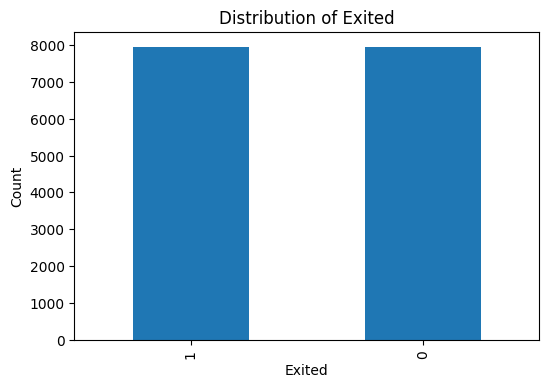

In [ ]:

counts = df_balanced_smote['Exited'].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind='bar')

plt.xlabel('Exited')
plt.ylabel('Count')
plt.title('Distribution of Exited')
plt.show()


a. boxplot

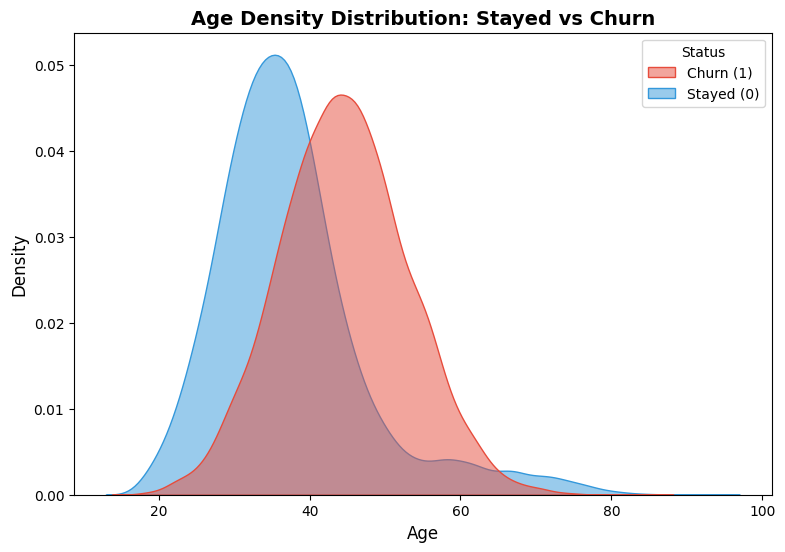

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_balanced_smote.copy()

df_plot['Status'] = df_plot['Exited'].map({0: 'Stayed (0)', 1: 'Churn (1)'})

warna_pasti = {'Stayed (0)': '#3498db', 'Churn (1)': '#e74c3c'}

plt.figure(figsize=(9, 6))

sns.kdeplot(
    data=df_plot,
    x='Age',
    hue='Status',
    fill=True,
    common_norm=False,
    palette=warna_pasti,
    alpha=0.5
)

plt.title('Age Density Distribution: Stayed vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)


plt.show()

b. NumOfProducts used vs churned

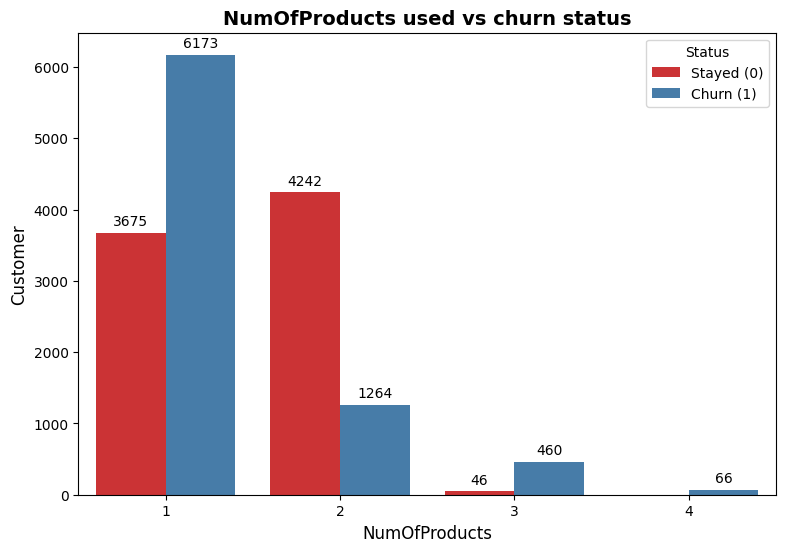

In [ ]:
plt.figure(figsize=(9, 6))
ax = sns.countplot(data=df_balanced_smote, x='NumOfProducts', hue='Exited', palette='Set1')

plt.title('NumOfProducts used vs churn status', fontsize=14, fontweight='bold')
plt.xlabel('NumOfProducts', fontsize=12)
plt.ylabel('Customer', fontsize=12)
plt.legend(title='Status', labels=['Stayed (0)', 'Churn (1)'])


for p in ax.patches:
    tinggi = p.get_height()
    if tinggi > 0:
        ax.annotate(f'{int(tinggi)}',
                    (p.get_x() + p.get_width() / 2., tinggi),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3), textcoords='offset points')

plt.show()

c. account balance

/tmp/ipykernel_1345/2518997053.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_balanced_smote, x='Exited', y='Balance', palette='Pastel1', inner='quartile')


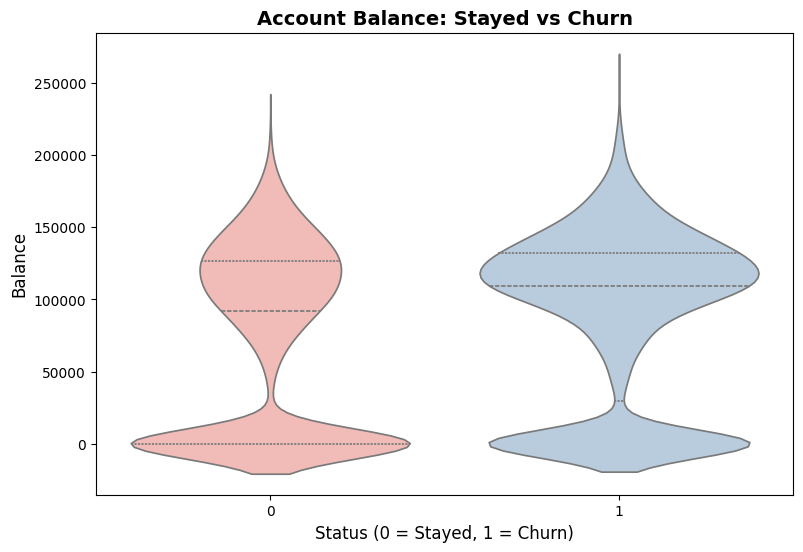

In [ ]:
plt.figure(figsize=(9, 6))
sns.violinplot(data=df_balanced_smote, x='Exited', y='Balance', palette='Pastel1', inner='quartile')

plt.title('Account Balance: Stayed vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Status (0 = Stayed, 1 = Churn)', fontsize=12)
plt.ylabel('Balance', fontsize=12)

plt.show()

d. age distribution

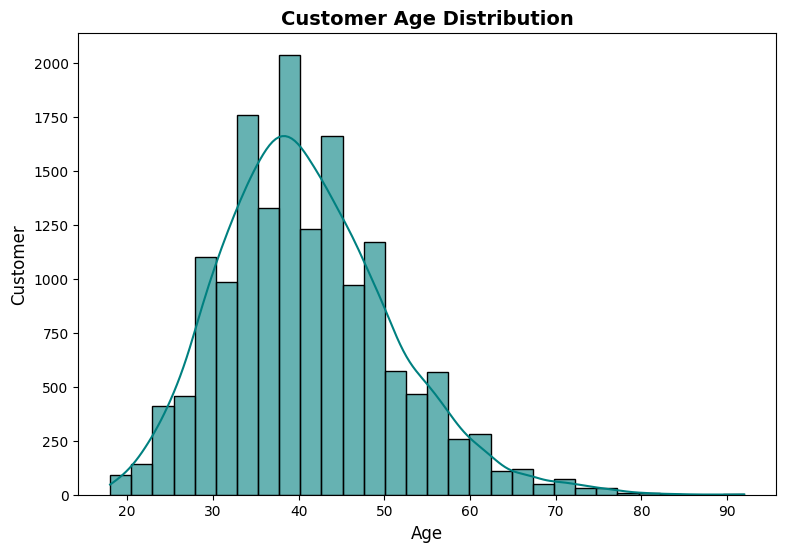

In [ ]:
plt.figure(figsize=(9, 6))

sns.histplot(data=df_balanced_smote, x='Age', bins=30, kde=True, color='teal', alpha=0.6)

plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Customer', fontsize=12)

plt.show()

e. ActiveMembership vs Churn

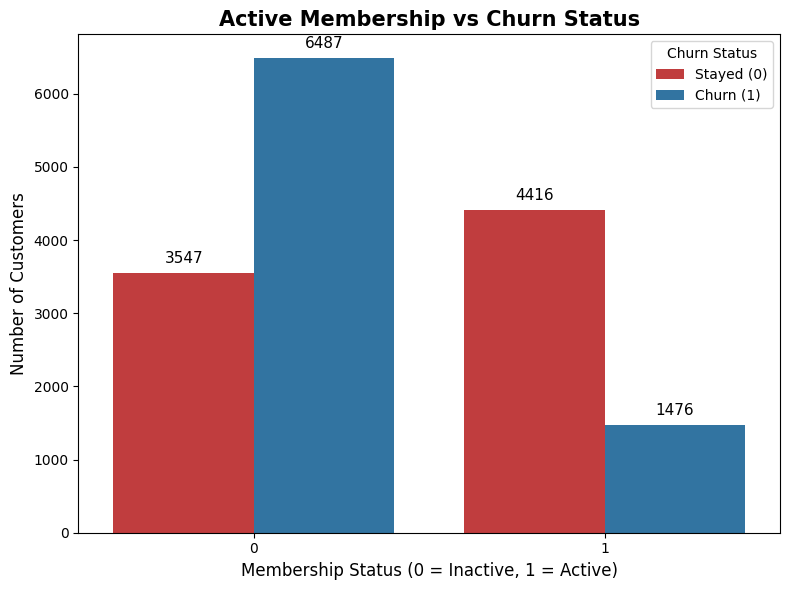

In [ ]:

plt.figure(figsize=(8, 6))

ax = sns.countplot(x='IsActiveMember', hue='Exited', data=df_balanced_smote, palette={0: '#d62728', 1: '#1f77b4'})

plt.title('Active Membership vs Churn Status', fontsize=15, fontweight='bold')
plt.xlabel('Membership Status (0 = Inactive, 1 = Active)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.legend(title='Churn Status', labels=['Stayed (0)', 'Churn (1)'])

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, color='black',
                    xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

f. Heatmap

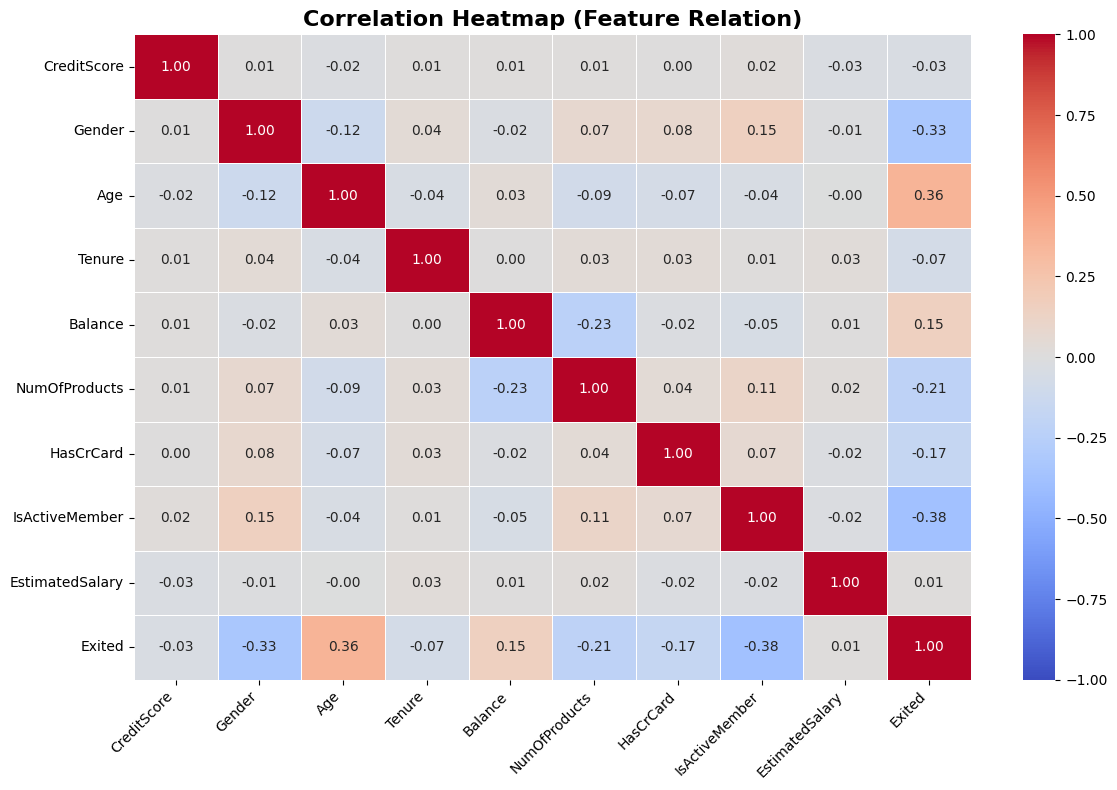

In [ ]:
plt.figure(figsize=(12, 8))

correlation_matrix = df_balanced_smote.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap (Feature Relation)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

4. Saving Dataset

In [7]:

path_output = '/content/drive/MyDrive/KULIAH/DSAI/Dataset/bank_churn_balanced_smote.csv'
df_balanced_smote.to_csv(path_output, index=False)

print(f"Saved as: bank_churn_balanced_smote.csv")

Saved as: bank_churn_balanced_smote.csv
